---
title: Data-Centric AI (Module II)
subtitle: "From Domain Features to Automated Feature Selection"
---

## Learning outcomes

By the end of this notebook, you should be able to:

- Create reproducible manual features.
- Integrate feature construction into a pipeline.
- Distinguish feature engineering from feature selection.
- Compare filter and wrapper selection methods.
- Evaluate predictive performance, stability, and computational cost.

## 1. Feature engineering versus feature selection

**Feature engineering** creates candidate inputs for a model. It turns domain knowledge into measurable variables: ratios, differences, calendar effects, interaction terms, nonlinear transformations, and aggregations.

**Feature selection** chooses a subset of candidate inputs. It tries to keep signal while removing redundancy, noise, computational cost, and sources of overfitting.

A useful feature usually has at least one of these properties:

- It carries **signal** about the target.
- It is not just a duplicate of another feature.
- It is stable across samples, folds, and time periods.
- It is available at the moment the model is used.
- It does not encode the answer through leakage.

Feature engineering introduces hypotheses about the problem; feature selection controls complexity. Neither should inspect validation or test data.

## 2. Flight delay prediction

The synthetic dataset predicts whether a flight arrives at least 15 minutes late.


In [1]:
#| echo: false
# Import the tools needed for reproducible feature engineering, selection, and evaluation.
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE, SelectKBest, VarianceThreshold, SequentialFeatureSelector, mutual_info_classif
from sklearn.metrics import balanced_accuracy_score, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [ ]:
#| echo: false
rng = np.random.default_rng(42)
n = 5_000

airports = np.array(["ATL", "BOS", "JFK", "LAX", "SFO"])
carriers = np.array(["AA", "DL", "UA", "WN", "B6"])

# Schedule and route
scheduled_departure = (pd.Timestamp("2025-01-01") + pd.to_timedelta(rng.integers(0, 365, n), unit="D") + pd.to_timedelta(rng.integers(0, 24, n), unit="h") + pd.to_timedelta(rng.choice([0, 10, 15, 20, 30, 40, 45, 50], n), unit="m"))
origin = rng.choice(airports, n)
destination = rng.choice(airports, n)

while (origin == destination).any():
    mask = origin == destination
    destination[mask] = rng.choice(airports, mask.sum())

# Synthetic distance is sufficient for this feature-engineering exercise.
distance_km = rng.integers(300, 4_500, n)
scheduled_duration_min = np.round(35 + distance_km / 12.5).astype(int)
scheduled_arrival = scheduled_departure + pd.to_timedelta(scheduled_duration_min, unit="m")

# Correlated duplicate wind sensors
true_wind = np.clip(rng.gamma(2.3, 5, n), 0, 45)
weather_wind1 = np.clip(true_wind + rng.normal(0, 1.3, n), 0, None)
weather_wind2 = np.clip(true_wind + rng.normal(0, 1.7, n), 0, None)

# Correlated duplicate precipitation sensors
true_rain = np.where(rng.random(n) < 0.40, rng.gamma(1.8, 5.5, n), 0,)
weather_rain1 = np.clip(true_rain + rng.normal(0, 0.7, n), 0, None)
weather_rain2 = np.clip(true_rain + rng.normal(0, 1, n), 0, None)

df = pd.DataFrame(
    {
        "scheduled_departure": scheduled_departure,
        "scheduled_arrival": scheduled_arrival,
        "carrier": rng.choice(carriers, n),
        "origin": origin,
        "destination": destination,
        "distance_km": distance_km,
        "weather_wind1": weather_wind1.round(2),
        "weather_wind2": weather_wind2.round(2),
        "weather_rain1": weather_rain1.round(2),
        "weather_rain2": weather_rain2.round(2),
        "noise_1": rng.normal(0, 1, n).round(4),
        "noise_2": rng.uniform(-1, 1, n).round(4),
        "noise_3": rng.integers(0, 100, n),
    }
)

# Engineered features
holidays = pd.to_datetime(["2025-01-01","2025-01-20","2025-02-17","2025-05-26","2025-07-04","2025-09-01","2025-11-27","2025-12-24","2025-12-25","2025-12-31",])

df = df.assign(
    route=df["origin"] + "-" + df["destination"],
    scheduled_duration_min=scheduled_duration_min,
    departure_hour=df["scheduled_departure"].dt.hour,
    is_holiday=(df["scheduled_departure"].dt.normalize().isin(holidays) | df["scheduled_departure"].dt.dayofweek.eq(6)).astype(int),
)

df = df.assign(
    is_late_night=((df["departure_hour"] >= 20) | (df["departure_hour"] <= 4)).astype(int),
    high_precipitation=(df["weather_rain1"] >= 12).astype(int),
)

df = df.assign(
    holiday_late_night=df["is_holiday"] * df["is_late_night"],
    airport_limited_visibility=(((df["destination"] == "SFO") | (df["origin"] == "SFO")) & (df["distance_km"] > 1500) & (rng.random(n) < 0.6)).astype(int),
)

# Delay probability: requested rules receive strong coefficients.
delay_probability = 1 / (1 + np.exp(-(-0.6 + 3.0 * df["holiday_late_night"] + 2.7 * df["high_precipitation"] + 3.2 * df["airport_limited_visibility"])))
delay_event = rng.random(n) < delay_probability

# Generate arrival-delay magnitude.
arrival_delay_min = (rng.normal(-3, 6, n) + delay_event * rng.gamma(2.2, 8, n) + df["holiday_late_night"] * rng.gamma(2.5, 9, n) + df["high_precipitation"] * rng.gamma(2.8, 10, n) + df["airport_limited_visibility"] * rng.gamma(2.5, 12, n) + np.maximum(df["weather_rain1"] - 20, 0) * 0.8).round().clip(-20, 300).astype(int)

df["departure_delay_min"] = (
    0.65 * np.maximum(arrival_delay_min, 0) + rng.normal(0, 7, n)
).round().clip(-10, 240).astype(int)

df["actual_departure"] = df["scheduled_departure"] + pd.to_timedelta(
    df["departure_delay_min"], unit="m"
)

df["actual_arrival"] = df["scheduled_arrival"] + pd.to_timedelta(
    arrival_delay_min, unit="m"
)

# Calculate the target from the timestamps.
df["arrival_delay_min"] = ((df["actual_arrival"] - df["scheduled_arrival"]).dt.total_seconds().div(60).astype(int))
df["delayed_15_min"] = (df["arrival_delay_min"] >= 15).astype(int)

# Keep the full dataframe for teaching/auditing the synthetic rules.
delay_rule_summary = df.groupby(
    ["holiday_late_night", "high_precipitation", "airport_limited_visibility"]
)["delayed_15_min"].agg(["count", "sum", "mean"]).round(3)

# The model input starts from raw, prediction-time columns plus actual timestamps for the leakage discussion.
# We deliberately remove rule columns such as `holiday_late_night` and `high_precipitation` so students must recreate them.
engineered_rule_columns = [
    "route",
    "departure_hour",
    "is_holiday",
    "is_late_night",
    "high_precipitation",
    "holiday_late_night",
    "airport_limited_visibility",
]
leaky_outcome_columns = ["departure_delay_min", "arrival_delay_min", "delayed_15_min"]
X = df.drop(columns=engineered_rule_columns + leaky_outcome_columns)
y = df["delayed_15_min"].rename("arrival_delay_15min")

# Persist a copy for students who want to inspect the generated data outside the notebook.
# df.to_csv("synthetic_flight_delays.csv", index=False)
# df.groupby(["is_holiday", "is_late_night", "high_precipitation", "airport_limited_visibility"]).agg({"delayed_15_min": ["count", "sum", "mean"]}).round(2)
# df.groupby(["airport_limited_visibility"]).agg({"delayed_15_min": ["count", "sum", "mean"]}).round(2)


In [3]:
X.head(n=3)

,scheduled_departure,scheduled_arrival,carrier,origin,destination,distance_km,weather_wind1,weather_wind2,weather_rain1,weather_rain2,noise_1,noise_2,noise_3,scheduled_duration_min,actual_departure,actual_arrival
0,2025-02-02 04:15:00,2025-02-02 06:03:00,UA,ATL,SFO,918,4.76,5.09,0.56,0.00,0.4405,0.2071,83,108,2025-02-02 04:39:00,2025-02-02 06:45:00
1,2025-10-10 00:10:00,2025-10-10 03:11:00,AA,JFK,LAX,1826,26.43,26.82,0.84,0.00,1.8638,0.7937,27,181,2025-10-10 00:06:00,2025-10-10 03:10:00
2,2025-08-27 15:30:00,2025-08-27 19:18:00,B6,JFK,BOS,2409,2.80,0.83,13.91,12.32,1.1118,-0.6341,29,228,2025-08-27 16:23:00,2025-08-27 20:40:00


In [4]:
y.head(n=3)

0    1
1    0
2    1
Name: arrival_delay_15min, dtype: int64

## 4. Data understanding


In [5]:
y.value_counts(normalize=True).rename("class_share")

arrival_delay_15min
0    0.6068
1    0.3932
Name: class_share, dtype: float64

## 4. Data understanding


In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   scheduled_departure     5000 non-null   datetime64[us]
 1   scheduled_arrival       5000 non-null   datetime64[us]
 2   carrier                 5000 non-null   str           
 3   origin                  5000 non-null   str           
 4   destination             5000 non-null   str           
 5   distance_km             5000 non-null   int64         
 6   weather_wind1           5000 non-null   float64       
 7   weather_wind2           5000 non-null   float64       
 8   weather_rain1           5000 non-null   float64       
 9   weather_rain2           5000 non-null   float64       
 10  noise_1                 5000 non-null   float64       
 11  noise_2                 5000 non-null   float64       
 12  noise_3                 5000 non-null   int64         
 13 

## 5. Manual feature engineering

Create domain-inspired features from raw columns to encode hypotheses and help the model:

- `departure_hour`, `day_of_week`, `month`, `is_holiday`: scheduled date/time decomposition.
- `airport_*`: fixed airport-presence indicators for airports appearing in either origin or destination.
- Other?


In [7]:
#| echo: false
# Define a sklearn-compatible transformer so feature engineering is fitted inside pipelines.
class FlightFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, add_manual_features=True, include_actual_times=False, drop_datetime=True):
        self.add_manual_features = add_manual_features
        self.include_actual_times = include_actual_times
        self.drop_datetime = drop_datetime

    def fit(self, X, y=None):
        airports = pd.unique(pd.concat([X["origin"], X["destination"]], ignore_index=True))
        self.airport_categories_ = sorted(airports)
        self.holidays_ = pd.to_datetime([
            "2025-01-01", "2025-01-20", "2025-02-17", "2025-05-26", "2025-07-04",
            "2025-09-01", "2025-11-27", "2025-12-24", "2025-12-25", "2025-12-31",
        ])
        return self

    def transform(self, X):
        X_out = X.copy()
        scheduled_departure = pd.to_datetime(X_out["scheduled_departure"])
        scheduled_arrival = pd.to_datetime(X_out["scheduled_arrival"])
        holidays = getattr(
            self,
            "holidays_",
            pd.to_datetime([
                "2025-01-01", "2025-01-20", "2025-02-17", "2025-05-26", "2025-07-04",
                "2025-09-01", "2025-11-27", "2025-12-24", "2025-12-25", "2025-12-31",
            ]),
        )
        airport_categories = getattr(
            self,
            "airport_categories_",
            sorted(pd.unique(pd.concat([X_out["origin"], X_out["destination"]], ignore_index=True))),
        )

        if self.include_actual_times:
            actual_departure = pd.to_datetime(X_out["actual_departure"])
            actual_arrival = pd.to_datetime(X_out["actual_arrival"])
            X_out["actual_departure_hour"] = actual_departure.dt.hour
            X_out["actual_arrival_hour"] = actual_arrival.dt.hour
            X_out["actual_departure_delay_min"] = (actual_departure - scheduled_departure).dt.total_seconds() / 60
            X_out["actual_arrival_delay_min"] = (actual_arrival - scheduled_arrival).dt.total_seconds() / 60
            X_out["actual_elapsed_min"] = (actual_arrival - actual_departure).dt.total_seconds() / 60

        if self.add_manual_features:
            X_out["departure_hour"] = scheduled_departure.dt.hour
            X_out["day_of_week"] = scheduled_departure.dt.dayofweek
            X_out["month"] = scheduled_departure.dt.month
            X_out["is_weekend"] = X_out["day_of_week"].isin([5, 6]).astype(int)
            X_out["is_holiday"] = (scheduled_departure.dt.normalize().isin(holidays) | scheduled_departure.dt.dayofweek.eq(6)).astype(int)

            for airport in airport_categories:
                X_out[f"airport_{airport}"] = ((X_out["origin"] == airport) | (X_out["destination"] == airport)).astype(int)

        if self.drop_datetime:
            datetime_columns = ["scheduled_departure", "scheduled_arrival", "actual_departure", "actual_arrival"]
            X_out = X_out.drop(columns=[column for column in datetime_columns if column in X_out.columns])
        return X_out


## Can this column exist at prediction time, and did we create it from future data?


In [8]:
#| echo: false
# Compare safe and leaky engineered schemas before fitting any model.
safe_engineered_view = FlightFeatureEngineer(add_manual_features=True, include_actual_times=False, drop_datetime=False,).transform(X)
leaky_engineered_view = FlightFeatureEngineer(add_manual_features=True, include_actual_times=True).transform(X)

manual_feature_names = {
    "departure_hour", "day_of_week", "month", "is_weekend", "is_holiday", "is_late_night",
    "km_per_minute", "mean_wind_kmh", "mean_rain_mm", "wind_sensor_gap", "rain_sensor_gap",
    "high_precipitation", "holiday_late_night", "sfo_long_route", "route",
}
actual_time_feature_names = {
    "actual_departure", "actual_arrival", "actual_departure_hour", "actual_arrival_hour",
    "actual_departure_delay_min", "actual_arrival_delay_min", "actual_elapsed_min",
}

availability_notes = {
    "scheduled_departure": "before departure",
    "scheduled_arrival": "before departure",
    "actual_departure": "after departure",
    "actual_arrival": "after arrival",
    "actual_departure_hour": "after departure",
    "actual_arrival_hour": "after arrival",
    "actual_departure_delay_min": "after departure",
    "actual_arrival_delay_min": "after arrival",
    "actual_elapsed_min": "after arrival",
}

all_schema_columns = list(dict.fromkeys(list(X.columns) + list(leaky_engineered_view.columns)))
schema_rows = []

for column in all_schema_columns:
    if column in X.columns:
        dtype = X[column].dtype
        source = "raw"
    else:
        dtype = leaky_engineered_view[column].dtype
        source = "engineered"

    if column in actual_time_feature_names:
        keep_for_predeparture = "drop"
        leakage_risk = "high"
    elif column in safe_engineered_view.columns or column in X.columns:
        keep_for_predeparture = "candidate"
        leakage_risk = "low"
    else:
        keep_for_predeparture = "review"
        leakage_risk = "unknown"

    if column in actual_time_feature_names:
        selection_comment = "May score very high, but must be excluded because it is future information."
    elif column in manual_feature_names:
        selection_comment = "SelectKBest keeps it only if its mutual-information score is among the top k."
    else:
        selection_comment = "Candidate feature; keep only if available at prediction time and useful."

    schema_rows.append({
        "feature": column,
        "dtype": str(dtype),
        "source": source,
        "availability": availability_notes.get(column, "before departure"),
        "feature_family": "actual-time leakage" if column in actual_time_feature_names else "manual/domain" if column in manual_feature_names else "raw input",
        "predeparture_decision": keep_for_predeparture,
        "leakage_risk": leakage_risk,
        "selection_comment": selection_comment,
    })

feature_schema = pd.DataFrame(schema_rows)
schema_display_columns = ["feature", "dtype", "source", "availability"]
feature_schema.loc[feature_schema["source"] == "raw", schema_display_columns].sort_values(by=["availability", "source"], ascending=False)

# print("Safe engineered dataframe shape:", safe_engineered_view.shape)
# print("With actual-time features shape:", leaky_engineered_view.shape)

,feature,dtype,source,availability
0,scheduled_departure,datetime64[us],raw,before departure
1,scheduled_arrival,datetime64[us],raw,before departure
2,carrier,str,raw,before departure
3,origin,str,raw,before departure
4,destination,str,raw,before departure
5,distance_km,int64,raw,before departure
6,weather_wind1,float64,raw,before departure
7,weather_wind2,float64,raw,before departure
8,weather_rain1,float64,raw,before departure
9,weather_rain2,float64,raw,before departure


## Can this column exist at prediction time, and did we create it from future data?


In [9]:
#| echo: false
feature_schema.loc[feature_schema["source"] == "engineered", schema_display_columns].sort_values(by=["availability", "source"], ascending=False)

,feature,dtype,source,availability
21,departure_hour,int32,engineered,before departure
22,day_of_week,int32,engineered,before departure
23,month,int32,engineered,before departure
24,is_weekend,int64,engineered,before departure
25,is_holiday,int64,engineered,before departure
26,airport_ATL,int64,engineered,before departure
27,airport_BOS,int64,engineered,before departure
28,airport_JFK,int64,engineered,before departure
29,airport_LAX,int64,engineered,before departure
30,airport_SFO,int64,engineered,before departure


## Data understanding and visualization

In [10]:
#| echo: false
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def check_correlations(X, y, include_actual_times=True, thr=0.6):
    # Combine engineered X and target y
    df_corr = pd.concat(
        [
            FlightFeatureEngineer(
                add_manual_features=True,
                include_actual_times=include_actual_times,
                drop_datetime=False,
            ).transform(X),
            y,
        ],
        axis=1,
    ).copy()

    # Convert datetime columns to Unix timestamps in seconds
    for col in df_corr.select_dtypes(include=["datetime", "datetime64"]).columns:
        df_corr[col] = df_corr[col].astype("int64") // 10**9

    # Compute correlation matrix
    corr = df_corr.corr(numeric_only=True)

    # Ignore identity correlations
    non_identity = ~np.eye(len(corr), dtype=bool)

    # Keep variables with at least one non-identity |correlation| > thr
    keep = (corr.abs().gt(thr) & non_identity).any(axis=1)

    # Always retain the y column(s)
    y_columns = [y.name] if isinstance(y, pd.Series) else list(y.columns)
    keep.loc[corr.index.intersection(y_columns)] = True

    filtered_corr = corr.loc[keep, keep]

    # Plot filtered correlation matrix
    if filtered_corr.empty:
        print(f"No non-identity correlations with |correlation| > {thr}.")
    else:
        plt.figure(figsize=(12, 9))
        sns.heatmap(
            filtered_corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            linewidths=0.5,
        )
        plt.title(f"Variables with at least one |correlation| > {thr}")
        plt.tight_layout()
        plt.show()

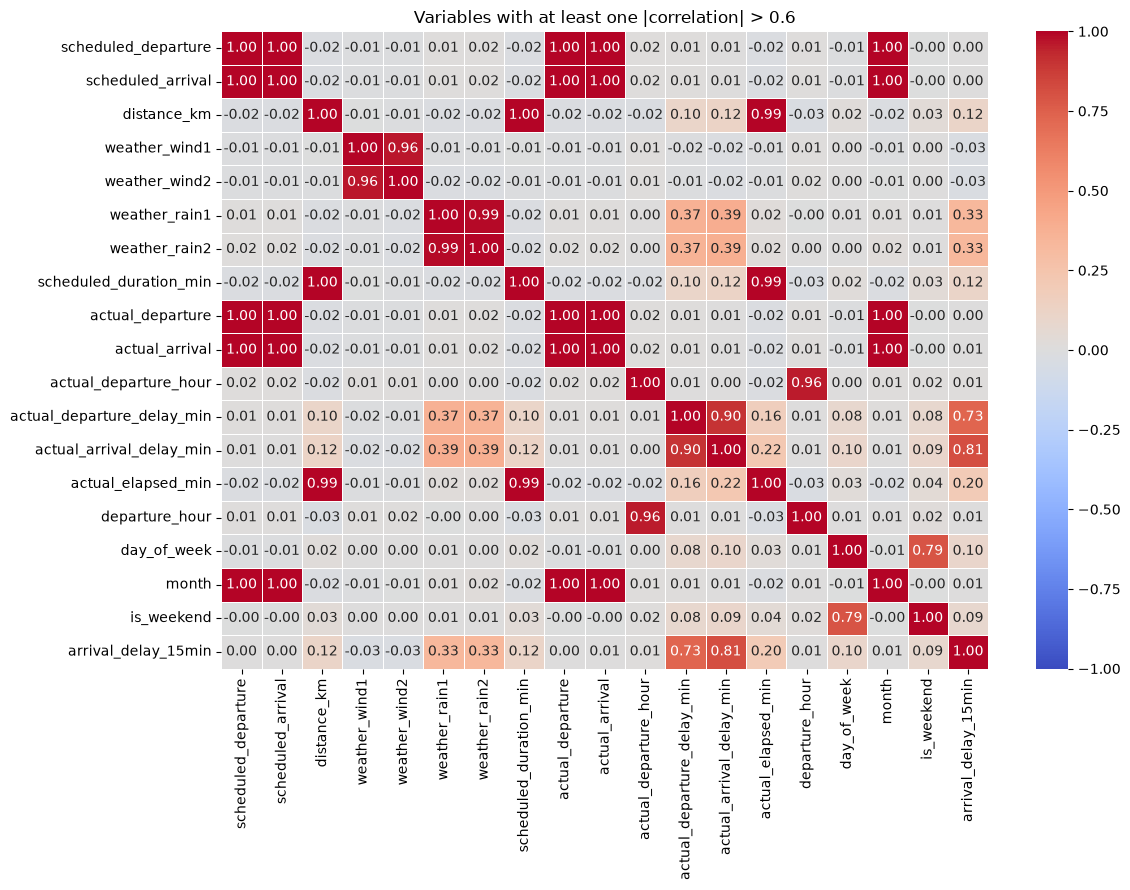

In [11]:
check_correlations(X, y)

## Data understanding and visualization

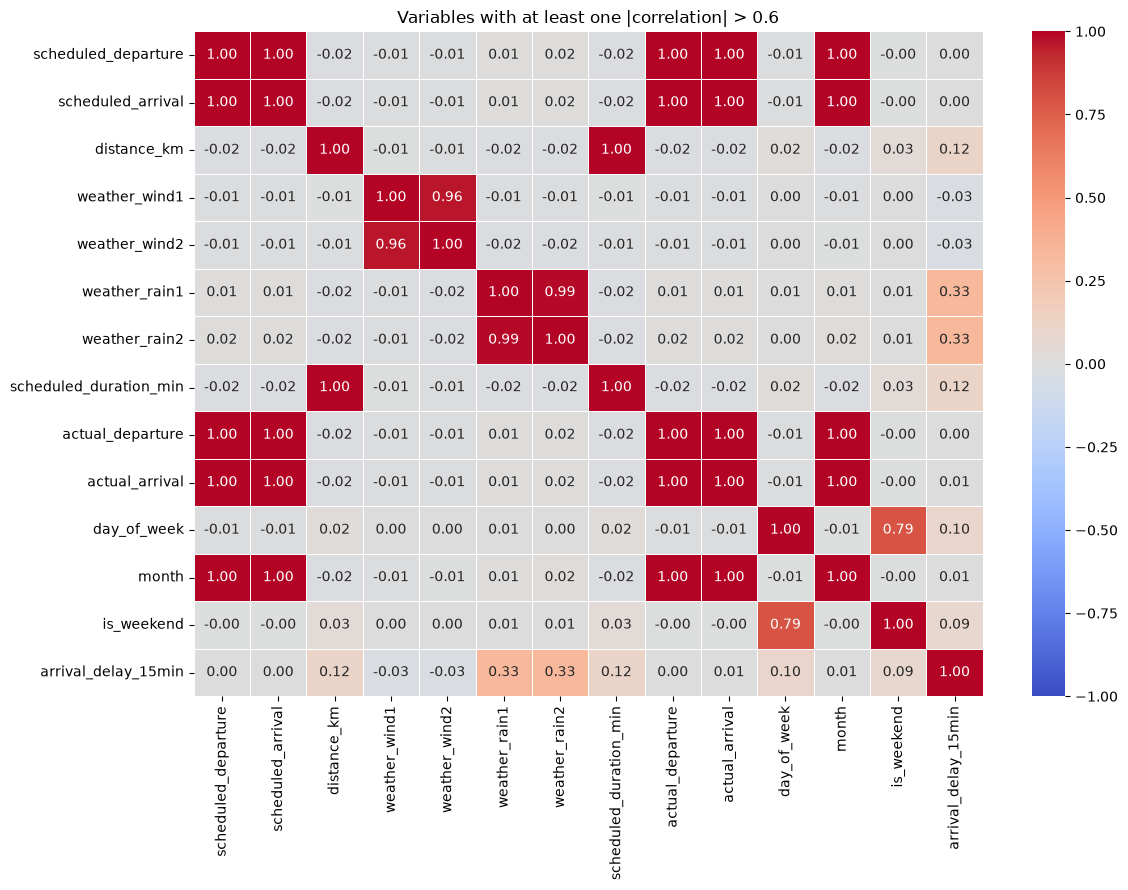

In [12]:
check_correlations(X, y, include_actual_times=False)

## 6. Pipeline generation

In [26]:
#| echo: false
# Build reusable preprocessing and classifier helpers for the later experiments.
def numeric_columns(X):
    return X.select_dtypes(include=np.number).columns.tolist()


def categorical_columns(X):
    return X.select_dtypes(exclude=np.number).columns.tolist()


def make_preprocessor():
    try:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("variance", VarianceThreshold())]), numeric_columns),
            ("cat", one_hot, categorical_columns),
        ],
        verbose_feature_names_out=False,
    )


def make_tree(max_depth=5, min_samples_leaf=1):
    return DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=RANDOM_STATE)

def mutual_info_reproducible(X_array, y_array):
    return mutual_info_classif(X_array, y_array, random_state=RANDOM_STATE)


def make_pipeline(add_manual_features=False, include_actual_times=False, selector=None):
    steps = [
        ("feature_engineering", FlightFeatureEngineer(add_manual_features=add_manual_features, include_actual_times=include_actual_times)),
        ("preprocessing", make_preprocessor()),
    ]
    if selector is not None:
        steps.append(("feature_selection", selector)) # Selection is part of model fitting. Keeping it inside the pipeline prevents validation-fold information from guiding the selected features.
    steps.append(("classifier", make_tree()))
    return Pipeline(steps)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1": make_scorer(f1_score),
}
make_pipeline(add_manual_features=False)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,add_manual_features,False
,include_actual_times,False
,drop_datetime,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be for

## 7. Actual departure and arrival times: keep or drop?

Prediction time matters:

- *Ticket sale*: route, carrier, scheduled times, and planned distance/duration.
- *Morning of travel*: forecasts and known schedule pressure.
- *Gate before departure*: current weather and operational status that is already known.
- *After departure*: actual departure time and departure delay may be inferred.
- *After landing*: actual arrival time and arrival delay are known.


In [ ]:
#| echo: false
# Demonstrate how future information can inflate validation metrics.
leakage_demo = {
    "Raw data - no feature engineering": make_pipeline(add_manual_features=False),
    "Feature engineering": make_pipeline(add_manual_features=True),
    "Leaky feature engineering": make_pipeline(add_manual_features=True, include_actual_times=True),
}
leakage_rows = []
for name, estimator in leakage_demo.items():
    result = cross_validate(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_estimator=True,)
    leakage_rows.append({
        "experiment": name,
        "balanced_accuracy_mean": result["test_balanced_accuracy"].mean(),
        "f1_mean": result["test_f1"].mean(),
    })


display(pd.DataFrame(leakage_rows))


,experiment,balanced_accuracy_mean,f1_mean
0,Raw data - no feature engineering,0.757822,0.702689
1,Feature engineering,0.790393,0.745900
2,Leaky feature engineering,1.000000,1.000000


## 8. Automated feature selection

We compare two families of selectors:

- **Filter methods** rank features using a statistical criterion independent of the final model. Here we use mutual information with `SelectKBest`.
    - Filter methods are usually faster. *Why?*
- **Wrapper methods** search for a subset by repeatedly fitting a model. Here we use `SequentialFeatureSelector` and `RFE`.
    - Wrapper methods can capture model-specific usefulness, but they are more computationally expensive. *Why?*

Important: selection is inside the pipeline. During cross-validation, the selector is fitted only on each training fold.


In [15]:
n_features_to_select = 10

# Filter: `SelectKBest`

`SelectKBest` sorts features by the score returned by `score_func` and keeps the top `k`.

- It is univariate: each feature is scored one at a time. It can miss features that are useful only together, and it may keep redundant features if each one individually has high signal.
- With `mutual_info_classif`, select the features with the highest estimated mutual information with the class label.
    -  Mutual information is non-negative. A score near zero means the feature and target look almost independent under the estimator; a larger score means knowing the feature reduces more uncertainty about the class label.
- This does **not** mean the selected features are causal, non-leaky, or non-redundant.
- It only means they had the largest training-fold association with `y` according to the mutual-information estimator.


In [16]:
# Score each preprocessed feature by estimated mutual information with y. Keep only the k=n_features_to_select highest-scoring features inside each training fold.
filter_selector = SelectKBest(score_func=mutual_info_reproducible, k=n_features_to_select)


# Wrapper: `SequentialFeatureSelector`

Forward-SFS is a greedy procedure that iteratively finds the best new feature to add to the set of selected features. 

- Start with zero features and find the one feature that maximizes a cross-validated score when an estimator is trained on this single feature.
- Once that first feature is selected, repeat the procedure by adding a new feature to the set of selected features.
- Stop when the desired number of selected features is reached.

Backward-SFS follows the same idea but works in the opposite direction: it starts with all features and removes one feature at a time. In sklearn this is obtained with `SequentialFeatureSelector(direction="backward")`.


In [17]:
wrapper_selector = SequentialFeatureSelector(estimator=make_tree(), n_features_to_select=n_features_to_select, direction="forward", scoring="balanced_accuracy", cv=3, n_jobs=-1)


# Wrapper: `RFE`

Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), recursive feature elimination (RFE) selects features by recursively considering smaller and smaller sets of features.

- First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through any specific attribute (such as coef_, feature_importances_).
- Then, the least important features are pruned from the current set of features.
- That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.


In [18]:
rfe_selector = RFE(estimator=make_tree(), n_features_to_select=n_features_to_select, step=0.2)

`RFE` vs backward `SequentialFeatureSelector`: both methods remove features until the desired subset size is reached.

- **RFE** fits the estimator and removes the least important features according to the estimator's internal importance signal. With logistic regression, this usually means small coefficient magnitudes; with trees, it may mean feature importances.
    - asks *which feature does the fitted model currently consider weakest?*
- **Backward `SequentialFeatureSelector`** tries candidate removals and evaluates the resulting model with a scoring metric, here balanced accuracy. At each step, it removes the feature whose removal gives the best cross-validated score, or hurts the score least.
    - asks *which feature can I remove while preserving validation performance?*
- RFE is usually faster; backward SFS is usually more expensive but more directly tied to the chosen evaluation metric.

## 9. Compare raw, engineered, and selected feature sets

We measure predictive performance, number of selected features, and training time. We also keep the fitted estimators from cross-validation so we can inspect selection stability.

The experiment table compares predictive value, selected feature count, and runtime rather than optimizing only one number.


In [19]:
#| echo: false
# Run every feature strategy under the same stratified cross-validation protocol.

experiments = {
    "raw": make_pipeline(add_manual_features=False),
    "fe": make_pipeline(add_manual_features=True),
    "fe + wrapper (SFS)": make_pipeline(add_manual_features=True, selector=wrapper_selector),
    "fe + filter (SelectKBest)": make_pipeline(add_manual_features=True, selector=filter_selector),
    "fe + wrapper (RFE)": make_pipeline(add_manual_features=True, selector=rfe_selector),
}


def count_output_features(estimator):
    preprocessor = estimator.named_steps["preprocessing"]
    n_preprocessed = len(preprocessor.get_feature_names_out())
    selector = estimator.named_steps.get("feature_selection")
    if selector is None:
        return n_preprocessed
    return int(selector.get_support().sum())


rows = []
cv_results_by_name = {}

for name, estimator in experiments.items():
    start_time = time.perf_counter()
    result = cross_validate(estimator, X, y, cv=cv, scoring=scoring, return_estimator=True, n_jobs=-1)
    elapsed = time.perf_counter() - start_time
    cv_results_by_name[name] = result

    selected_counts = [count_output_features(fitted) for fitted in result["estimator"]]
    rows.append({
        "experiment": name,
        "balanced_accuracy_mean": result["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": result["test_balanced_accuracy"].std(),
        "f1_mean": result["test_f1"].mean(),
        "features_mean": np.mean(selected_counts),
        "features_std": np.std(selected_counts),
        "fit_time_total_sec": elapsed,
    })

summary = pd.DataFrame(rows).sort_values("balanced_accuracy_mean", ascending=False)
summary

,experiment,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,features_mean,features_std,fit_time_total_sec
2,fe + wrapper (SFS),0.790669,0.020160,0.746013,10.0,0.0,9.285895
1,fe,0.790393,0.020539,0.745900,34.0,0.0,1.078672
4,fe + wrapper (RFE),0.790139,0.019587,0.745617,10.0,0.0,0.203749
3,fe + filter (SelectKBest),0.763442,0.014965,0.715689,10.0,0.0,0.454076
0,raw,0.757822,0.021924,0.702689,24.0,0.0,1.119995


## 10. Selection stability across folds

A selector is more trustworthy when it keeps similar features across folds. Instability does not always mean the selector is wrong: correlated features may be interchangeable. But instability should make us cautious when interpreting selected variables as domain truth.

Stability is an interpretation check: selected features that change across folds should be discussed cautiously.


In [20]:
#| echo: false
# Measure how similar the selected feature sets are across validation folds.
def selected_feature_names_ordered(fitted_pipeline):
    """Return feature names in the exact order seen by the final estimator."""
    names = fitted_pipeline.named_steps["preprocessing"].get_feature_names_out()
    selector = fitted_pipeline.named_steps.get("feature_selection")
    if selector is None:
        return list(names)
    return list(names[selector.get_support()])


def selected_feature_names(fitted_pipeline):
    return set(selected_feature_names_ordered(fitted_pipeline))


def mean_jaccard(selected_sets):
    scores = []
    for i in range(len(selected_sets)):
        for j in range(i + 1, len(selected_sets)):
            union = selected_sets[i] | selected_sets[j]
            intersection = selected_sets[i] & selected_sets[j]
            scores.append(len(intersection) / len(union))
    return np.mean(scores)


stability_rows = []
for name, result in cv_results_by_name.items():
    if "+" not in name:
        continue
    selected_sets = [selected_feature_names(fitted) for fitted in result["estimator"]]
    stability_rows.append({
        "experiment": name,
        "mean_jaccard_similarity": mean_jaccard(selected_sets),
        "example_selected_features": sorted(list(selected_sets[0]))[:15],
    })

stability = pd.DataFrame(stability_rows).sort_values("mean_jaccard_similarity", ascending=False)
display(stability)

,experiment,mean_jaccard_similarity,example_selected_features
2,fe + wrapper (RFE),0.760606,"[airport_SFO, departure_hour, distance_km, is_..."
1,fe + filter (SelectKBest),0.455311,"[airport_LAX, airport_SFO, carrier_AA, destina..."
0,fe + wrapper (SFS),0.423168,"[airport_ATL, airport_JFK, airport_SFO, carrie..."


## 11. Performance versus number of features

A useful visualization is a performance-versus-number-of-features curve. Here we vary `k` for `SelectKBest`. A good choice is not necessarily the highest possible balanced accuracy: we may prefer a smaller model when the performance loss is negligible.

This curve helps students look for diminishing returns as more features are selected.


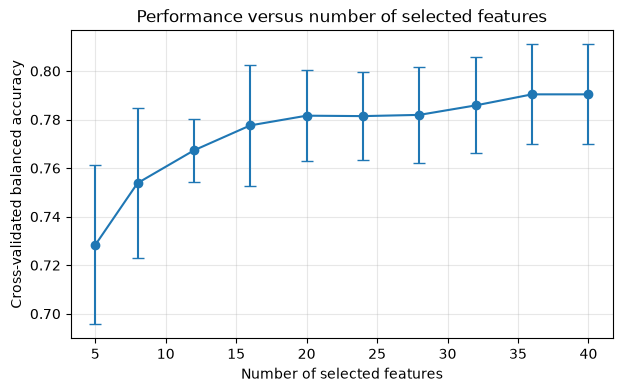

In [27]:
#| echo: false
# Vary the number of selected features to look for diminishing returns.
k_values = np.linspace(5, 40, 10, dtype=int)
curve_rows = []

for k in k_values:
    estimator = make_pipeline(
        add_manual_features=True,
        selector=SelectKBest(score_func=mutual_info_reproducible, k=k),
    )
    result = cross_validate(estimator, X, y, cv=cv, scoring={"balanced_accuracy": make_scorer(balanced_accuracy_score)}, n_jobs=-1)
    curve_rows.append({
        "k": k,
        "balanced_accuracy_mean": result["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": result["test_balanced_accuracy"].std(),
    })

curve = pd.DataFrame(curve_rows)
# display(curve)

plt.figure(figsize=(7, 4))
plt.errorbar(curve["k"], curve["balanced_accuracy_mean"], yerr=curve["balanced_accuracy_std"], marker="o", capsize=4)
plt.xlabel("Number of selected features")
plt.ylabel("Cross-validated balanced accuracy")
plt.title("Performance versus number of selected features")
plt.grid(alpha=0.3)
plt.show()

## 12. Interpretability check

In [22]:
chosen_pipeline = make_pipeline(add_manual_features=True, selector=wrapper_selector)
chosen_pipeline.fit(X, y)
selected_feature_names_for_tree = selected_feature_names_ordered(chosen_pipeline)
tree = chosen_pipeline.named_steps["classifier"]
pd.DataFrame({"selected_feature": selected_feature_names_for_tree})


,selected_feature
0,weather_rain1
1,scheduled_duration_min
2,departure_hour
3,month
4,is_weekend
5,is_holiday
6,airport_ATL
7,airport_BOS
8,airport_SFO
9,origin_SFO


## Plotting the tree

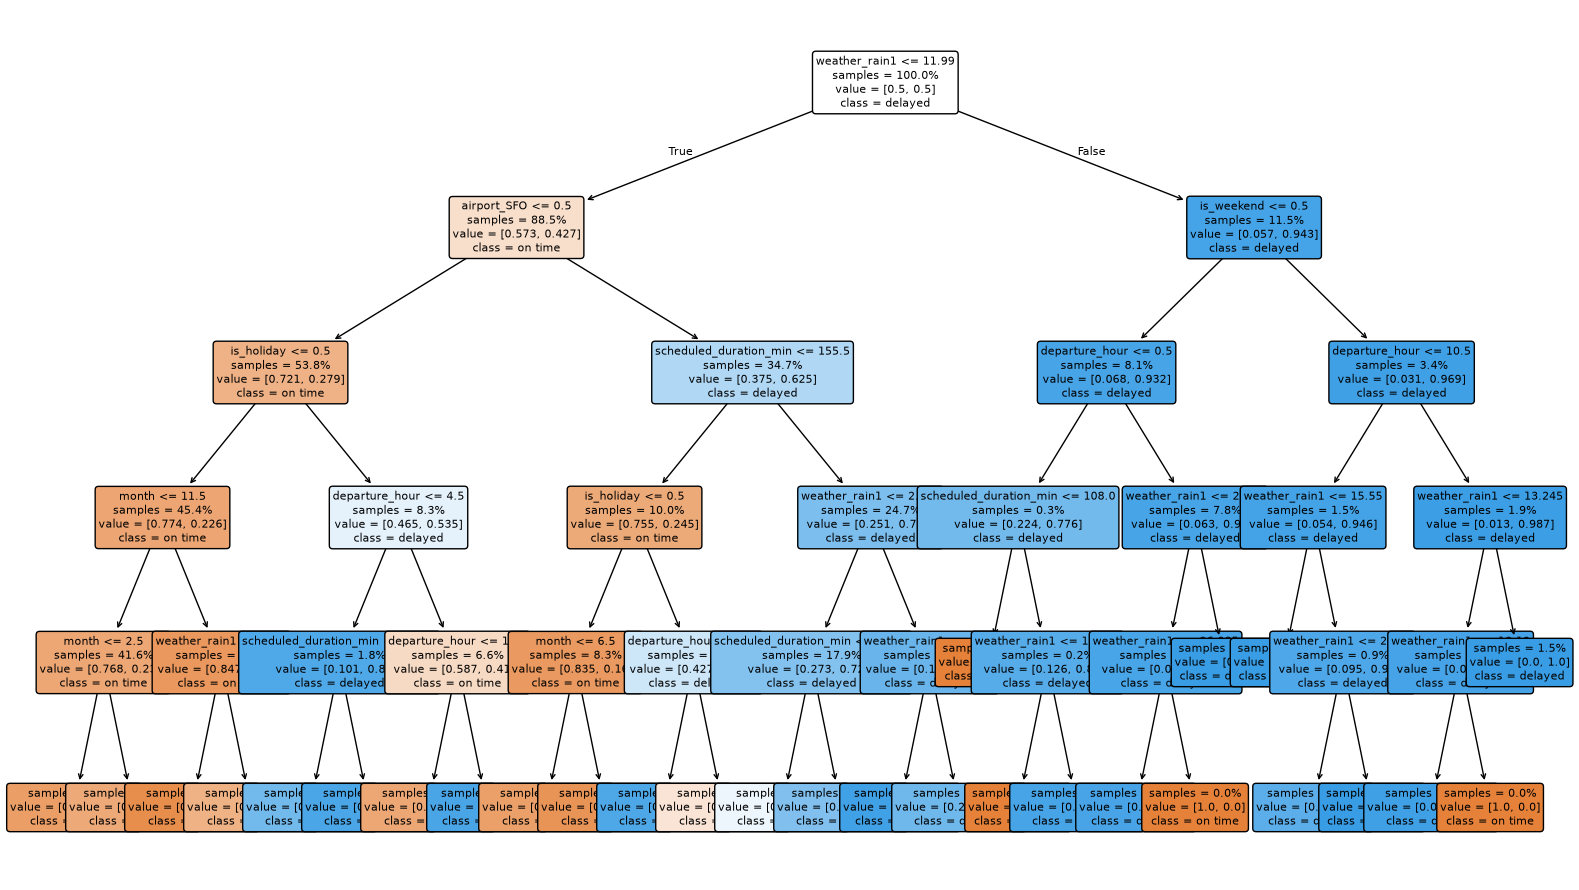

In [23]:
#| echo: false
plt.figure(figsize=(16, 9))
plot_tree(tree, feature_names=selected_feature_names_for_tree, class_names=["on time", "delayed"], filled=True, rounded=True, proportion=True, impurity=False, fontsize=8,)
plt.tight_layout()
plt.show()

## Checking tree feature importance

In [24]:
pd.DataFrame({
    "feature": selected_feature_names_for_tree,
    "importance": tree.feature_importances_,
})

,feature,importance
0,weather_rain1,0.349957
1,scheduled_duration_min,0.184063
2,departure_hour,0.107511
3,month,0.004678
4,is_weekend,0.000431
5,is_holiday,0.093707
6,airport_ATL,0.000000
7,airport_BOS,0.000000
8,airport_SFO,0.259653
9,origin_SFO,0.000000


## Permutation importance estimates how much the fitted decision tree depends on each selected feature.

In [25]:
#| echo: false
# Estimate importance for the exact features seen by the decision tree.
X_engineered = chosen_pipeline.named_steps["feature_engineering"].transform(X)
X_preprocessed = chosen_pipeline.named_steps["preprocessing"].transform(X_engineered)
selector = chosen_pipeline.named_steps.get("feature_selection")
if selector is None:
    X_tree = X_preprocessed
else:
    X_tree = selector.transform(X_preprocessed)

importance = permutation_importance(tree, X_tree, y, scoring="balanced_accuracy", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,)

importance_table = (
    pd.DataFrame({
        "tree_feature": selected_feature_names_for_tree,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)
importance_table


,tree_feature,importance_mean,importance_std
8,airport_SFO,0.140687,0.004698
0,weather_rain1,0.104646,0.003097
1,scheduled_duration_min,0.071498,0.003194
5,is_holiday,0.042902,0.002224
2,departure_hour,0.033005,0.002502
4,is_weekend,0.000899,0.000292
3,month,0.000000,0.000000
6,airport_ATL,0.000000,0.000000
7,airport_BOS,0.000000,0.000000
9,origin_SFO,0.000000,0.000000


## 13. Student challenge

Run feature engineering and selection on the California housing dataset from Kaggle.

- Which features are most predictive of median house value? Compare filter and wrapper methods, and evaluate predictive performance, stability, and computational cost.